In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import make_classification

In [15]:
X,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)

In [9]:
X

array([[-1.02874192, -0.91688796],
       [-1.43914415, -0.0957014 ],
       [ 0.66952197,  1.42414472],
       ...,
       [-0.63410688,  2.32283744],
       [ 0.70701889,  0.42141334],
       [-0.68978244,  2.12080759]])

In [7]:
y

array([0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0,

In [8]:
pd.DataFrame(X)[0]

,0
0,-1.028742
1,-1.439144
2,0.669522
3,0.138827
4,-1.013964
...,...
995,-2.127323
996,0.645441
997,-0.634107
998,0.707019


<Axes: xlabel='feature_0', ylabel='feature_1'>

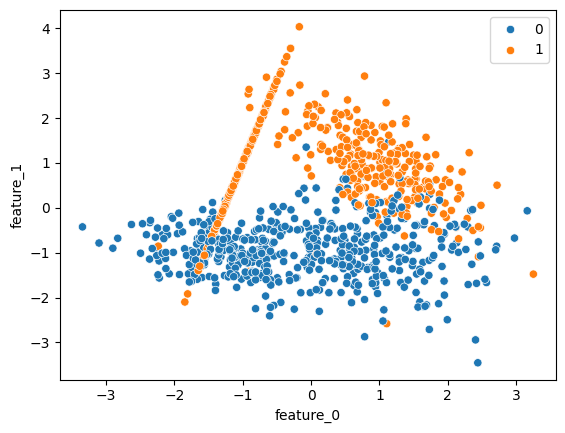

In [11]:
df = pd.DataFrame(X, columns=['feature_0', 'feature_1'])
sns.scatterplot(x='feature_0', y='feature_1', hue=y, data=df)

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=43)

In [19]:
from sklearn.svm import SVC

In [20]:
svc = SVC(kernel='linear')

In [21]:
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [25]:
y_pred = svc.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

In [27]:
accuracy_score(y_pred,y_test)

0.945

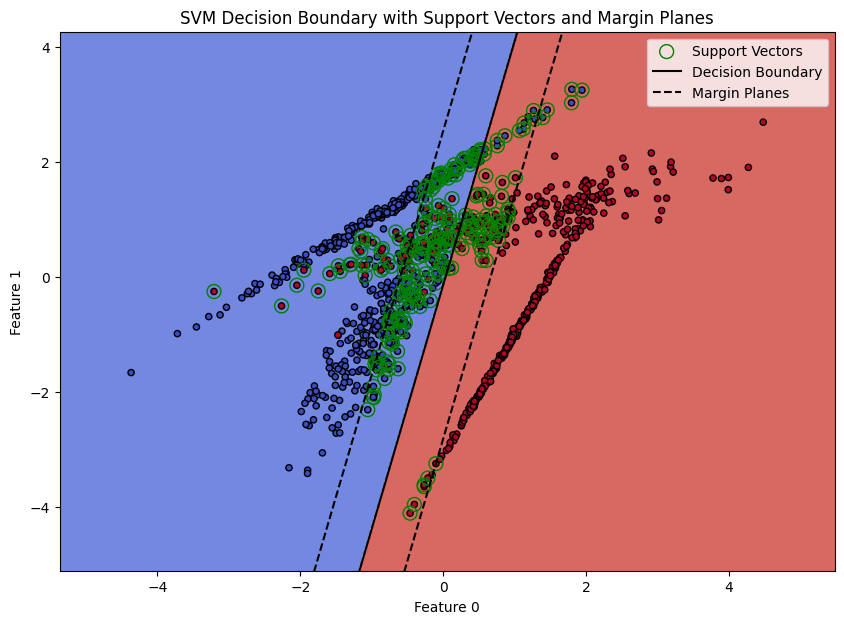

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Get min and max values for the features to define the plot boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Create a mesh grid to plot the decision boundary
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Predict class labels for each point on the mesh grid
Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and margins
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')

# Plot the support vectors
plt.scatter(svc.support_vectors_[:, 0],
            svc.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='green', label='Support Vectors')

# Plot the decision boundary and margin lines
w = svc.coef_[0]
a = -w[0] / w[1]
xx_line = np.linspace(x_min, x_max)
yy_line = a * xx_line - (svc.intercept_[0]) / w[1] # Decision Boundary

margin = 1 / np.sqrt(np.sum(w ** 2))
yy_down = yy_line - np.sqrt(1 + a ** 2) * margin # Lower Margin
yy_up = yy_line + np.sqrt(1 + a ** 2) * margin   # Upper Margin

plt.plot(xx_line, yy_line, 'k-', label='Decision Boundary')
plt.plot(xx_line, yy_down, 'k--', label='Margin Planes')
plt.plot(xx_line, yy_up, 'k--')

plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.title('SVM Decision Boundary with Support Vectors and Margin Planes')
plt.legend()
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()